# SAM original format

## 1. Mask generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gc        
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import cv2
from tqdm import tqdm
import os

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    del mask
    gc.collect()

def show_masks_on_image(raw_image, masks, random_color=True):
  plt.imshow(np.array(raw_image))
  ax = plt.gca()
  ax.set_autoscale_on(False)
  for mask in masks:
      show_mask(mask, ax=ax, random_color=random_color)
#   plt.axis("off")
  plt.show()
  del mask
  gc.collect()

def sort_3x3_row_major(points, attach = None):
    """
    将 3x3 点阵按 “从左到右, 从上到下” 排序。
    points: [(x,y), ...]，长度为8或9
    attach: 可选，与 points 一一对应的额外数组（标签/数值），会按同一顺序返回
    返回: (sorted_points, order, sorted_attach[可选])
    """
    # 1) 全局按 y 升序
    idx_by_y = sorted(range(len(points)), key=lambda i: points[i][1])

    # 2) 切成 3 行，每行 3 个；行内按 x 升序. 最终顺序（上→下，行内左→右）
    order = []
    if len(points) == 9:
        for r in range(3):
            row_idx = idx_by_y[r*3:(r+1)*3]
            row_idx_sorted = sorted(row_idx, key=lambda i: points[i][0])
            order.extend(row_idx_sorted)
    elif len(points) == 8:
        for r in range(3):
            if r == 0:
                row_idx = idx_by_y[:2]
            else:
                row_idx = idx_by_y[2+(r-1)*3:2+(r)*3]
            row_idx_sorted = sorted(row_idx, key=lambda i: points[i][0])
            order.extend(row_idx_sorted)
    else:
        raise ValueError("points 长度必须为8或9")

    sorted_points = [points[i] for i in order]

    # 3) 处理有9个色块的情况，去掉第一个点
    if len(points) == 9:
        order.pop(0)
        sorted_points.pop(0)
    if attach is None:
        return sorted_points, order
    else:
        assert len(attach) == len(points), "attach 长度需与 points 相同"
        sorted_attach = [attach[i] for i in order]
        return sorted_points, order, sorted_attach

In [2]:
# 1. 加载模型
sam_checkpoint = "/data/basemodel/sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint).to(device)

In [3]:
# 2. 构造自动分割器
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,       # 控制点的采样密度，越大越细致，耗时也更长
    pred_iou_thresh=0.95,     # 控制mask质量阈值
    stability_score_thresh=0.95,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=1000, # 过滤太小的mask
)

## 1) Test

### b. 大模型方法

In [4]:
# 3. 读取图像
raw_image = cv2.imread("/data/gas_8feat/raw/after/12.jpg")
raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)

In [10]:
import time

# 4. 生成mask
start_time = time.time()
masks = mask_generator.generate(raw_image)
print(f"生成mask耗时: {time.time() - start_time:.2f} 秒")

print(f"生成了 {len(masks)} 个mask")
print(masks[3].keys())
segmentation = [i['segmentation'] for i in masks]

生成mask耗时: 1.78 秒
生成了 14 个mask
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


In [6]:
print([i['area'] for i in masks])

[4142, 4323, 4139, 4037, 2834, 4420, 4199, 8470, 4244, 4448, 4710, 8550, 126, 149591]


In [19]:
[i['bbox'][2]/i['bbox'][3] for i in masks]

[1.0140845070422535,
 1.0136986301369864,
 0.9726027397260274,
 0.9859154929577465,
 1.0714285714285714,
 0.935064935064935,
 1.0138888888888888,
 1.9210526315789473,
 0.9726027397260274,
 1.0675675675675675,
 0.8674698795180723,
 0.6394557823129252,
 0.4666666666666667,
 1.359882005899705]

In [25]:
# segmentation = [i['segmentation'] for i in masks if i['area']>3500 and i['area']<4700 and 1.2 > i['bbox'][2]/i['bbox'][3] > 0.80]
segmentation = [i['segmentation'] for i in masks if i['area']>3700 and i['area']<4800 and 1.2 > i['bbox'][2]/i['bbox'][3] > 0.8]
print(len(segmentation))

9


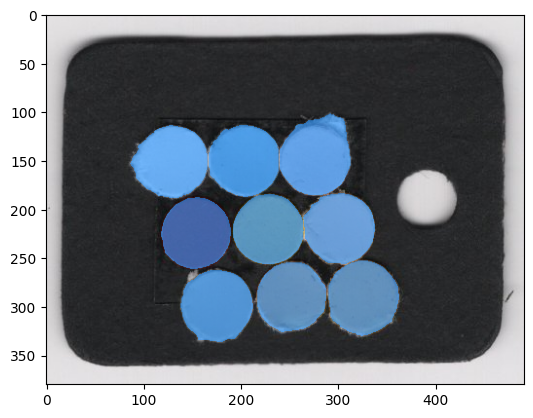

In [26]:
show_masks_on_image(raw_image, [i for i in segmentation], random_color=False)

In [28]:
from PIL import Image

img = np.array(Image.open("/data/gas_8feat/raw/before/108.jpg"))
x_avg = []
y_avg = []
# 每个mask
for i in range(len(segmentation)):
    coords = np.where(segmentation[i] == 1)
    x_avg.append(np.mean(coords[1]))
    y_avg.append(np.mean(coords[0]))
points = list(zip(x_avg, y_avg))
sorted_points, order = sort_3x3_row_major(points)
segmentation = np.array(segmentation)[order]
feat = []
for j in range(len(segmentation)):
    mask = segmentation[j]
    feat.extend(img[mask].mean(axis=0).tolist())

In [36]:
img = np.array(Image.open("/data/gas_8feat/raw/before/108.jpg"))
raw_image = cv2.imread("/data/gas_8feat/raw/before/108.jpg")
raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)

In [39]:
img = Image.open("/data/gas_8feat/raw/before/108.jpg")
print(img.getexif().get(0x0112))

3


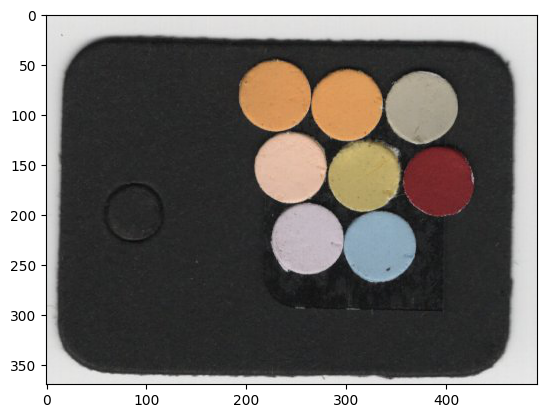

In [ ]:
plt.imshow(img)

In [29]:
feat

[39.99705449189985,
 40.249386352479135,
 40.1232204221895,
 174.06554580896687,
 145.80847953216374,
 128.44736842105263,
 38.766439909297056,
 39.0249433106576,
 38.78231292517007,
 40.13809990205681,
 40.415279138099905,
 40.32419196865818,
 152.30838835901199,
 143.63903154805575,
 147.99461971142088,
 39.7719806763285,
 40.13478260869565,
 39.96304347826087,
 38.967749876907924,
 39.44830132939439,
 39.20802560315116,
 40.34302467627657,
 40.634497923283654,
 41.0903982408991]

### 2) Implementation

In [5]:
# 3. 读取所有图像
import os

raw_paths = []
root = '/data/gas/images'
for dirpath, dirnames, filenames in os.walk(root):
    if len(filenames) > 0:
        raw_paths.extend([os.path.join(dirpath, f) for f in filenames])

In [6]:
len(raw_paths)

292

In [7]:
# 4. 生成所有mask并保存

import time

for raw_path in tqdm(raw_paths):
    # start = time.time()
    raw_image = cv2.imread(raw_path)
    raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    masks = mask_generator.generate(raw_image)
    masks_ = [i for i in masks if i['area']>15000 and i['area']<18000 and 1.15 > i['bbox'][2]/i['bbox'][3] > 0.85]
    seg = np.array([i['segmentation'] for i in masks_]).astype(np.uint8)
    dirname, basename = os.path.dirname(raw_path), os.path.basename(raw_path)
    save_path = dirname.replace('images', 'masks')
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    np.save(os.path.join(save_path, basename.replace('.jpg', '.npy')), seg)
    if len(masks_) != 9:
        print(raw_path, f"处理前有 {len(masks)} 个mask, 处理后有 {len(masks_)} 个mask")
    # print('用时:', time.time() - start)
print('finished')

  0%|          | 0/292 [00:49<?, ?it/s]


KeyboardInterrupt: 

## 2. Sort the masks

### 1) Test

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

seg = np.load('/data/gas/masks/patient/after/1.npy')
seg.shape

(9, 701, 980)

In [ ]:
x_avg = []
y_avg = []
for i in range(len(seg)):
        coords = np.where(seg[i] == 1)
        x_avg.append(np.mean(coords[1]))
        y_avg.append(np.mean(coords[0]))
points = list(zip(x_avg, y_avg))
print(points)

In [4]:
from typing import List, Tuple, Any, Optional

Point = Tuple[float, float]

def sort_3x3_row_major(points: List[Point], attach: Optional[List[Any]] = None):
    """
    将 3x3 点阵按 “从左到右, 从上到下” 排序。
    points: [(x,y), ...] 恰好 9 个点
    attach: 可选，与 points 一一对应的额外数组（标签/数值），会按同一顺序返回
    返回: (sorted_points, order, sorted_attach[可选])
    """
    assert len(points) == 9, "必须是 3x3 共 9 个点"
    # 1) 全局按 y 升序
    idx_by_y = sorted(range(9), key=lambda i: points[i][1])

    # 2) 切成 3 行，每行 3 个；行内按 x 升序
    rows = []
    for r in range(3):
        row_idx = idx_by_y[r*3:(r+1)*3]
        row_idx_sorted = sorted(row_idx, key=lambda i: points[i][0])
        rows.append(row_idx_sorted)

    # 3) 展平得到最终顺序（上→下，行内左→右）
    order = [i for row in rows for i in row]

    sorted_points = [points[i] for i in order]
    if attach is None:
        return sorted_points, order
    else:
        assert len(attach) == 9, "attach 长度需与 points 相同"
        sorted_attach = [attach[i] for i in order]
        return sorted_points, order, sorted_attach


In [ ]:
sorted_points, order = sort_3x3_row_major(points)

In [ ]:
plt.imshow(seg.sum(0))
plt.scatter(*sorted_points[8], s=1, c='red')

### Implementation

In [ ]:
import os
import numpy as np

mask_paths = []
root = '/data/gas/masks'
for dirpath, dirnames, filenames in os.walk(root):
    if len(filenames) > 0:
        mask_paths.extend([os.path.join(dirpath, f) for f in filenames])

# 每张图的所有mask
for p in mask_paths:
    seg = np.load(p)
    x_avg = []
    y_avg = []
    # 每个mask
    for i in range(len(seg)):
        coords = np.where(seg[i] == 1)
        x_avg.append(np.mean(coords[1]))
        y_avg.append(np.mean(coords[0]))
    points = list(zip(x_avg, y_avg))
    sorted_points, order = sort_3x3_row_major(points)
    seg = seg[order]
    save_path = p.replace('masks', 'masks_sorted')
    if not os.path.exists(os.path.dirname(save_path)):
        os.makedirs(os.path.dirname(save_path))
    np.save(save_path, seg)
print('finished!')
    

finished!


## 3. Extract RGB values

In [1]:
import PIL.Image as Image
import numpy as np
import pandas as pd
import os
import time
from tqdm import tqdm

In [2]:
# img_paths = []
normal_before_paths = []
normal_after_paths = []
patient_before_paths = []
patient_after_paths = []
root = '/data/gas_test/images'
for dirpath, dirnames, filenames in os.walk(root):
    if len(filenames) == 0:
        continue
    if 'normal' in dirpath and 'before' in dirpath:
        normal_before_paths.extend([os.path.join(dirpath, f) for f in filenames])
    if 'normal' in dirpath and 'after' in dirpath:
        normal_after_paths.extend([os.path.join(dirpath, f) for f in filenames])
    if 'patient' in dirpath and 'before' in dirpath:
        patient_before_paths.extend([os.path.join(dirpath, f) for f in filenames])
    if 'patient' in dirpath and 'after' in dirpath:
        patient_after_paths.extend([os.path.join(dirpath, f) for f in filenames])

In [3]:
names = ['normal_before', 'normal_after', 'patient_before', 'patient_after']
paths_list = [normal_before_paths, normal_after_paths, patient_before_paths, patient_after_paths]
for paths, name in zip(paths_list, names):
    features = []
    start = time.time()
    for p in tqdm(paths):
        img = Image.open(p)
        img = np.array(img)
        seg = np.load(p.replace('images', 'masks_sorted').replace('.jpg', '.npy')).astype(bool)
        feat = []
        for j in range(9):
            mask = seg[j]
            feat.extend(img[mask].mean(axis=0).tolist())
        features.append(feat)
    print(f"Processed {len(paths)} images from {root}, time elapsed: {time.time() - start:.2f} seconds")

    df = pd.DataFrame(features, columns=[f'{j}_{i}' for i in range(9) for j in ['R', 'G', 'B']]).round(6)
    ids = [os.path.basename(p).replace('.jpg', '') for p in paths]
    df.insert(0, 'file_name', ids)
    df['id'] = [int(i) for i in ids]
    df_sorted = df.sort_values(by='id', ascending=True)
    del df_sorted['id']
    save_dir = os.path.join(root.replace("images", "values"))
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    df_sorted.to_csv(os.path.join(save_dir, f"RGB_val_{name}.csv"), index=False)
    print(f"Features saved to RGB_val_{name}.csv")

  0%|          | 0/57 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/data/gas_test/masks_sorted/normal/before/129.npy'

## 4. Calculate RGB difference

In [44]:
root = '/data/gas/values'
normal_before = pd.read_csv(os.path.join(root, 'RGB_val_normal_before.csv'))
normal_after = pd.read_csv(os.path.join(root, 'RGB_val_normal_after.csv'))
patient_before = pd.read_csv(os.path.join(root, 'RGB_val_patient_before.csv')) 
patient_after = pd.read_csv(os.path.join(root, 'RGB_val_patient_after.csv'))

In [45]:
res_normal = normal_after.drop('file_name', axis=1, inplace=False) - normal_before.drop('file_name', axis=1, inplace=False)
res_normal = res_normal.round(6)
# res_normal.insert(0, 'file_name', normal_after['file_name'].apply(lambda x: x.replace('_after', '')))
res_normal.insert(0, 'file_name', normal_after['file_name'])
res_normal.to_csv(os.path.join(root, 'RGB_diff_normal.csv'), index=False)

In [46]:
res_patient = patient_after.drop('file_name', axis=1, inplace=False) - patient_before.drop('file_name', axis=1, inplace=False)
res_patient = res_patient.round(6)
# res_patient.insert(0, 'file_name', patient_after['file_name'].apply(lambda x: x.replace('_after', '')))
res_patient.insert(0, 'file_name', patient_after['file_name'])
res_patient.to_csv(os.path.join(root, 'RGB_diff_patient.csv'), index=False)

# CV2传统分割

In [25]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

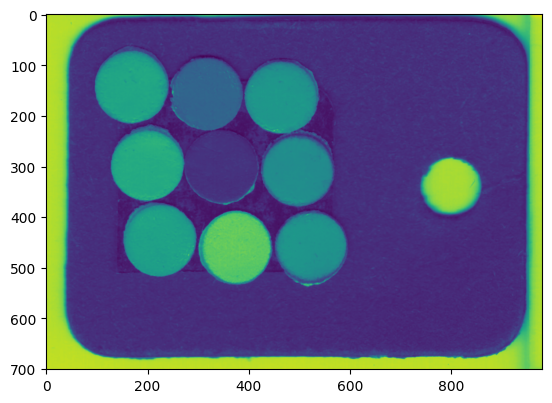

In [26]:
img = cv2.imread('/data/code/mywork/gas_sensor/1.jpg')
img = cv2.medianBlur(img, 3)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray)
plt.show()

连通域数量: 18


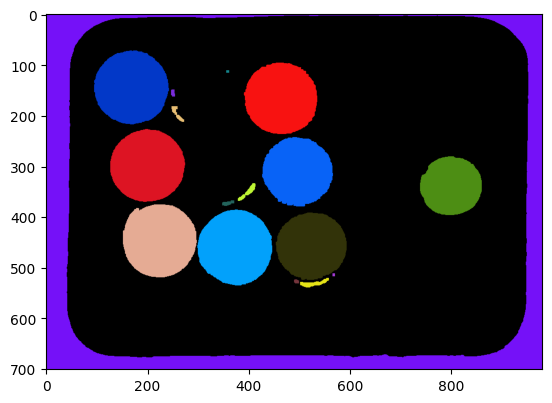

In [27]:
# 阈值分割得到二值化图片
ret, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

# 膨胀操作
kernel2 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
bin_clo = cv2.dilate(binary, kernel2, iterations=2)


# 连通域分析
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bin_clo, connectivity=8)

print('连通域数量:', num_labels)
# print('各连通域的统计信息:', stats)
# print('各连通域的质心坐标:', centroids)


# 不同的连通域赋予不同的颜色
output = np.zeros((img.shape[0], img.shape[1], 3), np.uint8)
for i in range(1, num_labels):
    mask = labels == i
    output[:, :, 0][mask] = np.random.randint(0, 255)
    output[:, :, 1][mask] = np.random.randint(0, 255)
    output[:, :, 2][mask] = np.random.randint(0, 255)

plt.imshow(output)
plt.show()

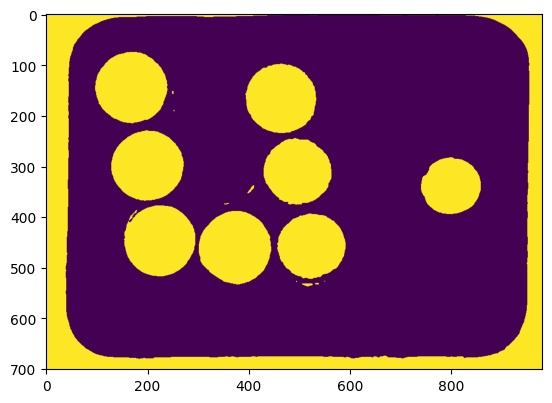

In [21]:
ret, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(binary)